In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import balanced_accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn import tree
import pickle

# Przygotowanie danych

In [2]:
data = pd.read_csv("Heart Prediction Quantum Dataset.csv")
data.drop("QuantumPatternFeature", axis=1)

,Age,Gender,BloodPressure,Cholesterol,HeartRate,HeartDisease
0,68,1,105,191,107,1
1,58,0,97,249,89,0
2,44,0,93,190,82,1
3,72,1,93,183,101,1
4,37,0,145,166,103,1
...,...,...,...,...,...,...
495,34,0,126,292,116,0
496,41,0,164,248,114,0
497,45,1,159,175,75,0
498,55,0,107,157,101,1


In [3]:
X = data.drop(labels="HeartDisease", axis=1)
Y = data["HeartDisease"]
X = X.to_numpy()
Y = Y.to_numpy()
X

array([[ 68.        ,   1.        , 105.        , 191.        ,
        107.        ,   8.36224069],
       [ 58.        ,   0.        ,  97.        , 249.        ,
         89.        ,   9.24900153],
       [ 44.        ,   0.        ,  93.        , 190.        ,
         82.        ,   7.94254206],
       ...,
       [ 45.        ,   1.        , 159.        , 175.        ,
         75.        ,   8.7187076 ],
       [ 55.        ,   0.        , 107.        , 157.        ,
        101.        ,   7.33764982],
       [ 55.        ,   0.        , 174.        , 249.        ,
         89.        ,  10.49295004]])

# Klasyfikacja

In [4]:
X_train, X_test, Y_train, Y_test = train_test_split(X,Y, test_size=0.39, random_state=1410)
print(X_train.shape, X_test.shape, Y_train, Y_test)

cls = DecisionTreeClassifier(random_state=1410, max_depth=7, splitter='best')
cls.fit(X_train,Y_train)

Y_predict = cls.predict(X_test)
bas = balanced_accuracy_score(Y_test,Y_predict)
bas

(305, 6) (195, 6) [1 1 0 1 0 1 1 1 0 0 1 1 0 1 1 1 0 1 1 1 0 1 1 1 1 0 1 0 0 1 0 0 1 1 1 1 1
 0 1 1 1 0 0 1 1 1 1 0 1 1 0 0 1 1 1 0 1 1 1 1 1 1 0 0 1 1 1 1 1 1 1 1 1 1
 1 0 1 1 1 0 1 1 0 1 1 1 1 0 0 1 0 1 1 0 0 0 1 1 1 0 0 1 1 1 1 1 1 1 1 1 1
 1 1 1 0 0 0 1 0 0 1 1 0 0 1 1 0 1 0 1 1 1 1 0 1 1 0 1 0 1 0 1 1 0 1 1 1 1
 1 0 1 1 0 1 1 0 1 1 0 1 1 0 1 1 0 1 1 0 1 0 1 0 0 0 0 0 1 0 1 0 1 1 0 0 0
 1 1 0 0 0 1 0 1 1 1 1 1 0 1 1 1 0 1 1 1 0 1 1 0 1 0 1 1 0 0 0 1 0 0 0 1 0
 1 1 1 0 1 1 0 1 0 0 0 1 1 0 1 0 1 0 1 1 0 1 0 0 0 0 1 0 1 1 0 0 1 1 0 0 0
 1 1 1 0 0 0 0 1 1 1 1 1 0 0 0 1 1 1 1 1 0 0 0 1 1 1 0 1 0 0 0 1 0 1 1 1 1
 1 1 0 1 1 0 1 0 0] [1 0 1 1 1 0 0 0 1 1 1 0 1 1 1 1 0 0 1 1 1 1 1 0 1 1 1 0 1 1 0 1 1 1 1 0 0
 0 1 1 1 1 0 1 1 1 1 0 1 1 1 0 1 0 0 1 0 0 1 1 1 1 1 1 1 1 0 1 1 1 0 1 1 1
 1 0 1 0 0 1 0 1 1 1 0 0 1 0 1 1 0 0 0 0 0 1 0 1 0 1 0 0 0 0 0 0 1 0 1 0 0
 0 0 0 0 0 1 1 0 1 1 1 1 0 0 1 0 1 0 1 0 0 1 0 1 0 0 1 1 1 0 1 1 0 1 1 1 0
 1 1 1 1 0 0 0 0 0 1 0 1 0 1 0 1 0 0 1 1 1 0 1 1 0 1 1 0 1 1 1

np.float64(0.9052989423699547)

# Wyświetlanie

[Text(0.43902439024390244, 0.9375, 'x[5] <= 8.535\ngini = 0.474\nsamples = 305\nvalue = [118, 187]'),
 Text(0.24390243902439024, 0.8125, 'x[5] <= 8.417\ngini = 0.054\nsamples = 181\nvalue = [5, 176]'),
 Text(0.3414634146341463, 0.875, 'True  '),
 Text(0.0975609756097561, 0.6875, 'x[5] <= 8.216\ngini = 0.023\nsamples = 172\nvalue = [2, 170]'),
 Text(0.04878048780487805, 0.5625, 'gini = 0.0\nsamples = 142\nvalue = [0, 142]'),
 Text(0.14634146341463414, 0.5625, 'x[5] <= 8.225\ngini = 0.124\nsamples = 30\nvalue = [2, 28]'),
 Text(0.0975609756097561, 0.4375, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.1951219512195122, 0.4375, 'x[2] <= 159.5\ngini = 0.067\nsamples = 29\nvalue = [1, 28]'),
 Text(0.14634146341463414, 0.3125, 'gini = 0.0\nsamples = 24\nvalue = [0, 24]'),
 Text(0.24390243902439024, 0.3125, 'x[2] <= 164.5\ngini = 0.32\nsamples = 5\nvalue = [1, 4]'),
 Text(0.1951219512195122, 0.1875, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.2926829268292683, 0.1875, 'gini = 0.0

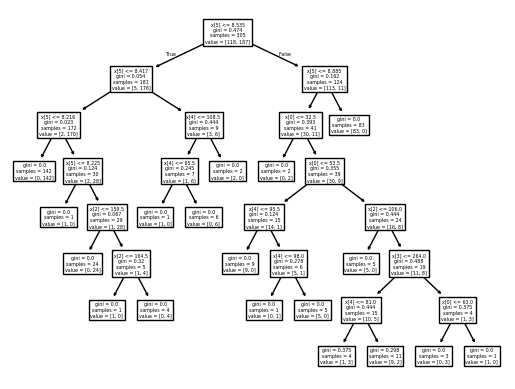

In [5]:
tree.plot_tree(cls)

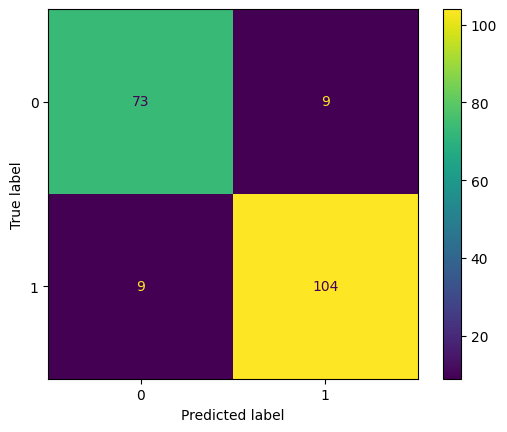

In [6]:
disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(Y_test,Y_predict))
disp.plot()

# Export Modelu

In [7]:
pickle.dump(cls, open("decision_tree.sv", "wb"))